In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy import constants
from lmfit.models import LinearModel

c = constants.c # Velocidad de la luz [m/s]
e = constants.e # Carga del electrón [C]
h = constants.h # Constante de Planck [eVs]

### 1. Graficas

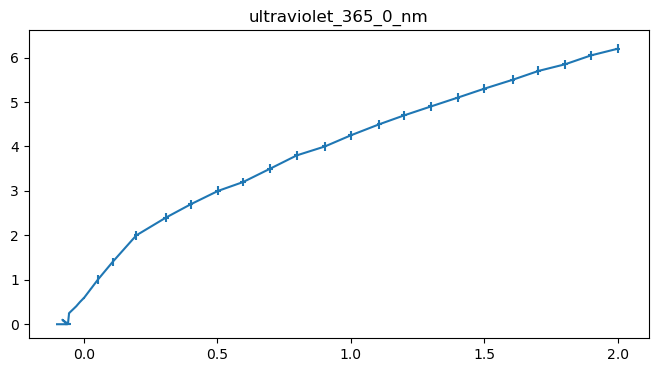

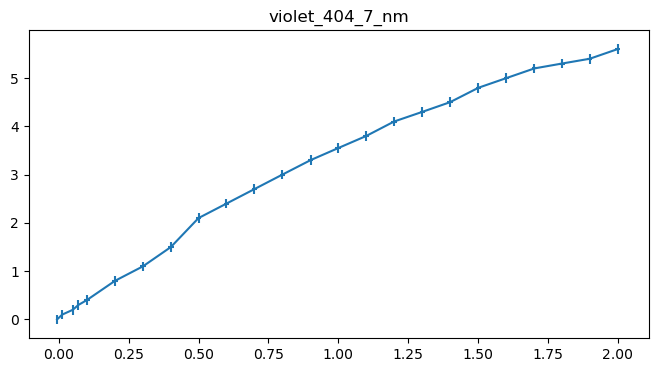

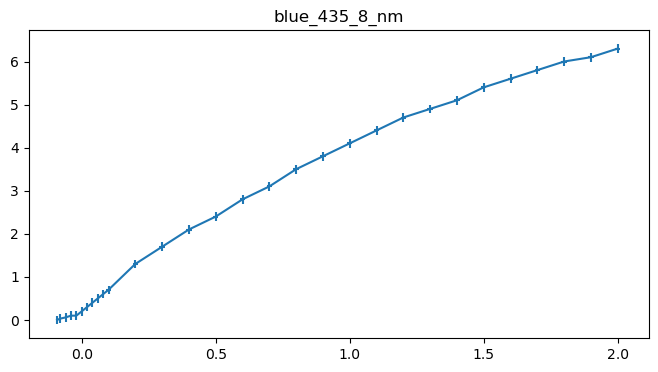

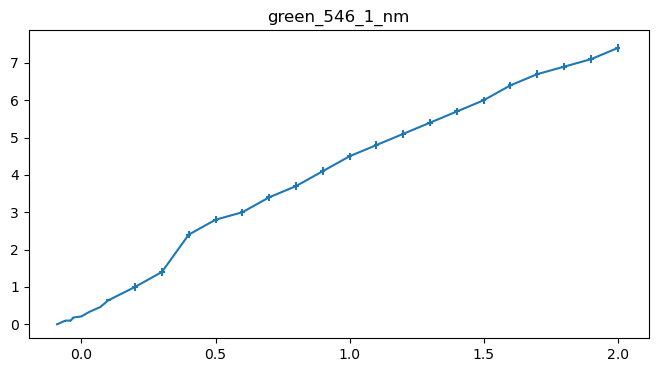

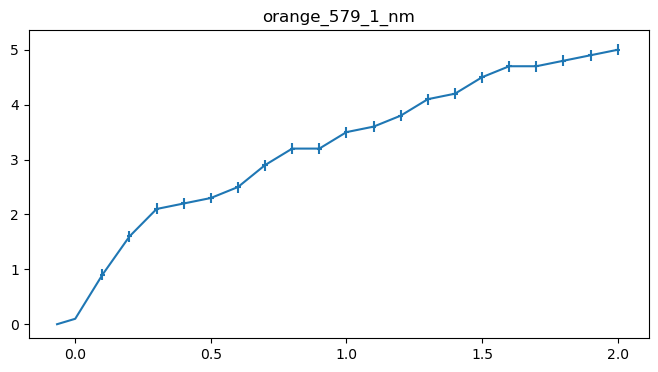

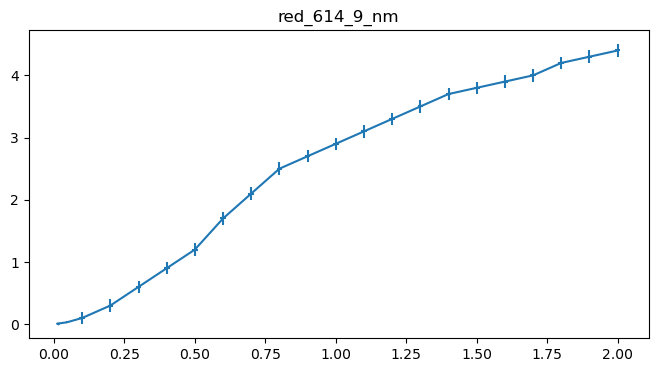

In [64]:
data_list = [ 'data_ultraviolet_365_0_nm_17_03_2026.csv', 'data_violet_404_7_nm_19_03_2026.csv',
             'data_blue_435_8_nm_19_03_2026.csv', 'data_green_546_1_nm_19_03_2026.csv',
            'data_orange_579_1_nm_24_03_2026.csv', 'data_red_614_9_nm_24_03_2026.csv']
for data_path in data_list:
    df = pd.read_csv('data/' + data_path) 
    I = df['I [nA]']
    dI = df['dI [nA]']
    V = df['V [V]']
    dV = df['dV [V]']

    fig, bx = plt.subplots(1, figsize=(8,4), dpi = 100)
    bx.errorbar(V,I,xerr= dV, yerr=dI)
    bx.set_title(data_path[5:-15])
    plt.show()

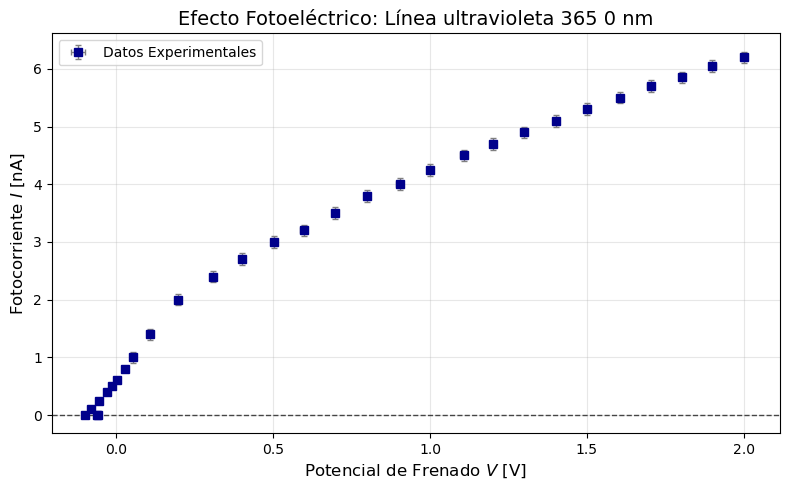

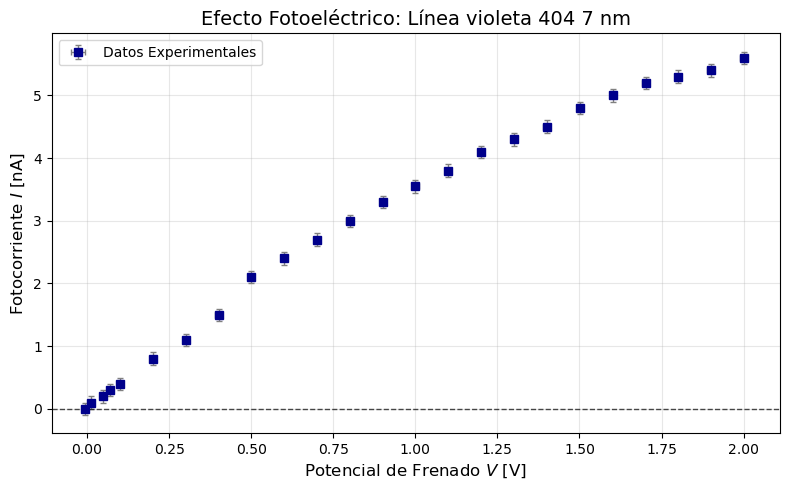

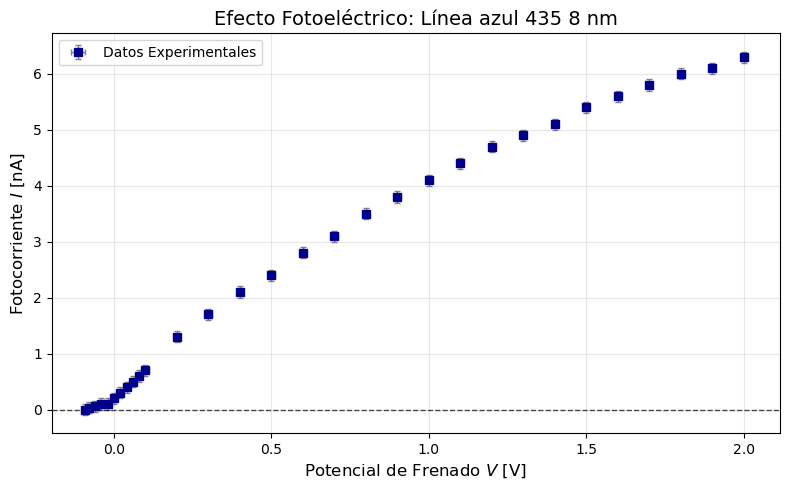

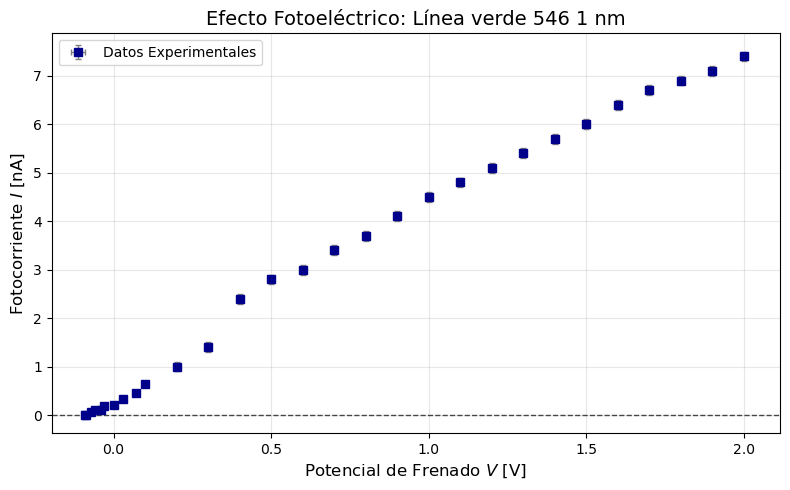

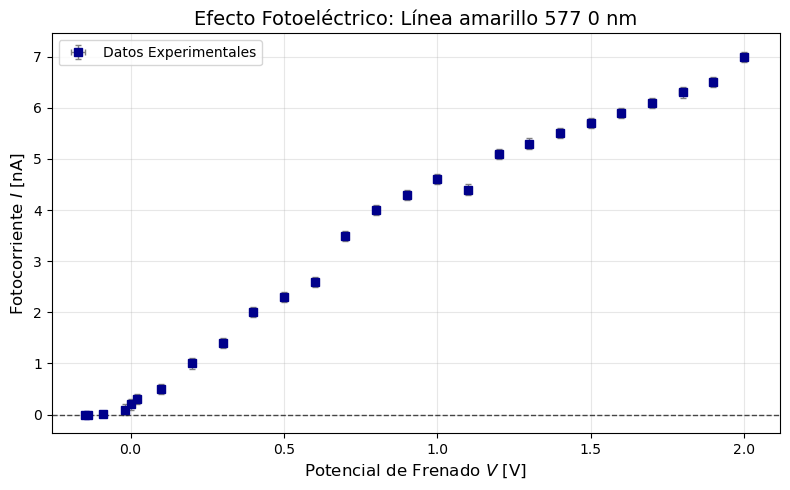

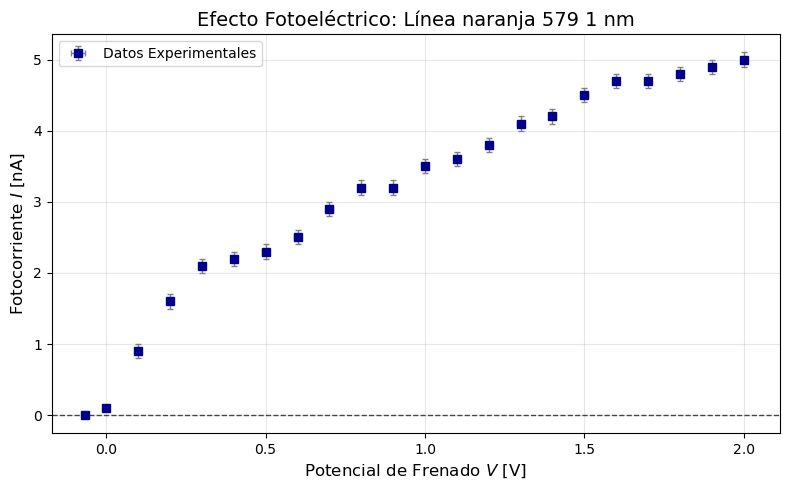

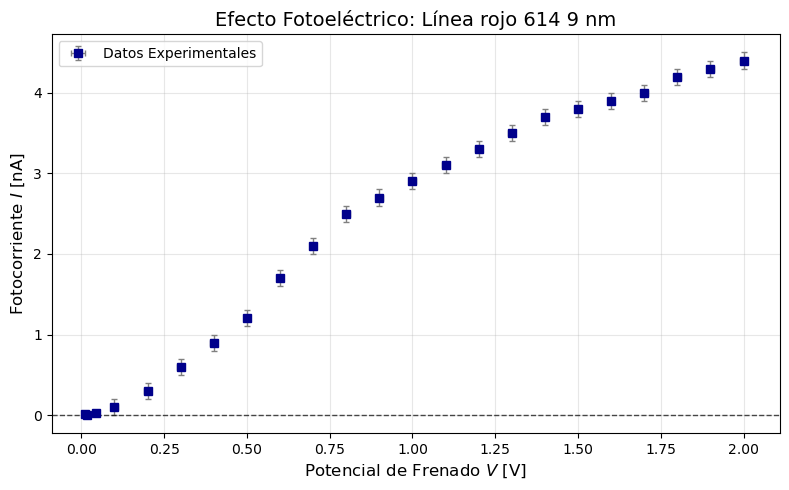

In [68]:
import matplotlib.pyplot as plt
import pandas as pd

# Configuración de estilo global para reporte
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'grid.alpha': 0.3
})

data_list = [ 'data_ultravioleta_365_0_nm_17_03_2026.csv', 'data_violeta_404_7_nm_19_03_2026.csv',
              'data_azul_435_8_nm_19_03_2026.csv', 'data_verde_546_1_nm_19_03_2026.csv',
              'data_amarillo_577_0_nm_24_03_2026.csv', 'data_naranja_579_1_nm_24_03_2026.csv',
             'data_rojo_614_9_nm_24_03_2026.csv']

for data_path in data_list:
    df = pd.read_csv('data/' + data_path) 
    I = df['I [nA]']
    dI = df['dI [nA]']
    V = df['V [V]']
    dV = df['dV [V]']

    # Crear figura con proporciones de reporte
    fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
    
    # Graficar con barras de error estilizadas
    ax.errorbar(V, I, xerr=dV, yerr=dI, fmt='s', color='darkblue', 
                ecolor='gray', elinewidth=1, capsize=2, label='Datos Experimentales')
    
    # Línea horizontal en I=0 para identificar visualmente el frenado
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
    
    # Limpiar el título extrayendo el nombre del color y la longitud de onda
    title_clean = data_path.replace('data_', '').replace('_', ' ').split('_')[0] # Ajustado según tu string
    ax.set_title(f"Efecto Fotoeléctrico: Línea {data_path[5:-15].replace('_', ' ')}")
    
    # Etiquetas de ejes con formato LaTeX
    ax.set_xlabel('Potencial de Frenado $V$ [V]')
    ax.set_ylabel('Fotocorriente $I$ [nA]')
    
    # Mejorar la rejilla y el layout
    ax.grid(True)
    ax.legend(loc='upper left')
    
    # Ajustar márgenes para que no se corte nada
    plt.tight_layout()
    
    # Guardar para el reporte (opcional)
    plt.savefig(f"plots/grafica_{data_path[:-4]}.png", dpi=300)
    
    plt.show()

### 2. Constante de Planck

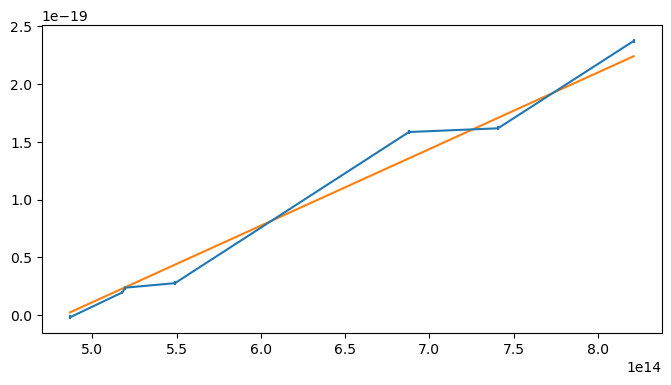

In [58]:
df = pd.read_csv('data/data_zeros_03_2026.csv')
A = df['lambda [nm]']
dA = df['dlambda [nm]']
V = df['V [V]']
dV = df['dV [V]']

f = c/(A*1e-9)
df = c*dA/(A**2)
E = -e*V
dE = e*dV

fig, bx = plt.subplots(1, figsize=(8,4), dpi = 100)
bx.errorbar(f,E,xerr= df, yerr=dE)
t = np.linspace(f.min(), f.max(),1000)
bx.plot(t, h*t-3.2e-19)
plt.show()

[[Model]]
    Model(linear)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 7
    # variables        = 2
    chi-square         = 7.9661e-40
    reduced chi-square = 1.5932e-40
    Akaike info crit   = -639.818794
    Bayesian info crit = -639.926974
    R-squared          = 1.00000000
[[Variables]]
    slope:      7.1312e-34 +/- 3.9316e-35 (5.51%) (init = 3.695425e-35)
    intercept: -3.5076e-19 +/- 2.4744e-20 (7.05%) (init = -3.917102e-20)
[[Correlations]] (unreported correlations are < 0.100)
    C(slope, intercept) = -0.9812


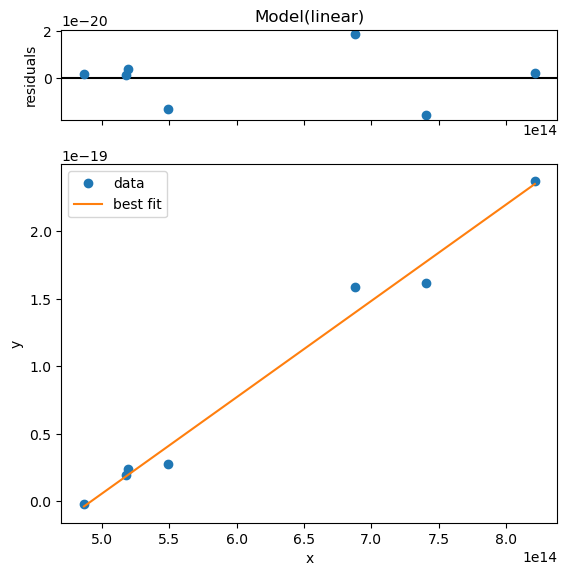

In [59]:
df = pd.read_csv('data/data_zeros_03_2026.csv')
A = df['lambda [nm]']
dA = df['dlambda [nm]']
V = df['V [V]']
dV = df['dV [V]']

f = c/(A*1e-9)
df = c*dA/(A**2)
E = -e*V
dE = e*dV

fig, bx = plt.subplots(1, figsize=(8,4), dpi = 100)
bx.errorbar(f,E,xerr= df, yerr=dE)
t = np.linspace(f.min(), f.max(),1000)
bx.plot(t, h*t-3.2e-19)
plt.show()

model = LinearModel()
result = model.fit(E, params, x=f)

print(result.fit_report())
result.plot()
plt.show()

In [60]:
H = result.params['slope'].value
H_err = result.params['slope'].stderr
err_per = np.abs(H - h) / h *100

print(f"Constante de Planck conocida: {h:.4e} Js")
print(f"Constante de Planck obtenida experimentalmente: {H:.4e} ± {H_err:.4e} Js")
print(f"Diferencia con el valor esperado: {err_per:.2f} %")

Constante de Planck conocida: 6.6261e-34 Js
Constante de Planck obtenida experimentalmente: 7.1312e-34 ± 3.9316e-35 Js
Diferencia con el valor esperado: 7.62 %


In [70]:
# 1. Asegúrate de cargar los datos de nuevo si el error persiste
df_lab = pd.read_csv('data/data_zeros_03_2026.csv')

# Extraer columnas (Usamos .values para asegurar que sean arreglos de numpy limpios)
lambdas = df_lab['lambda [nm]'].values
d_lambdas = df_lab['dlambda [nm]'].values
volts = df_lab['V [V]'].values
d_volts = df_lab['dV [V]'].values

# 2. Cálculos (Cuidando que todos operen sobre el mismo arreglo de origen)
f = c / (lambdas * 1e-9)
# Propagación de error: d f = |df/dl| * dl = (c/l^2) * dl
# Importante: el 1e-9 en el denominador para pasar nm a m está al cuadrado: (1e-9)^2
error_f = (c * d_lambdas) / ((lambdas * 1e-9)**2) * 1e-9 

E_joules = e * np.abs(volts)
error_E = e * d_volts

# Verificación de seguridad
if len(f) == len(E_joules):
    model = LinearModel()
    params = model.guess(E_joules, x=f)
    result = model.fit(E_joules, params, x=f, weights=1/error_E)
    print("¡Ajuste exitoso!")
else:
    print(f"ERROR DE TAMAÑO: f tiene {len(f)} y E tiene {len(E_joules)}")

¡Ajuste exitoso!


In [ ]:
# 1. Carga de datos y extracción de arreglos
df_lab = pd.read_csv('data/data_zeros_03_2026.csv')

# Usamos .values para asegurar que sean arreglos de numpy de la misma longitud
A_nm = df_lab['lambda [nm]'].values
dA_nm = df_lab['dlambda [nm]'].values
V_vals = df_lab['V [V]'].values
dV_vals = df_lab['dV [V]'].values

# 2. Cálculos físicos y Propagación de Errores
# Frecuencia f = c / lambda (convertido a metros)
f = c / (A_nm * 1e-9)

# Error en frecuencia: df = (c / lambda^2) * dlambda
# Multiplicamos por 1e-9 arriba y (1e-9)^2 abajo para que df esté en Hz
error_f = (c * dA_nm) / ((A_nm * 1e-9)**2) * 1e-9

# Energía cinética K = e * |V_frenado|
E_joules = e * np.abs(V_vals)
error_E = e * dV_vals

# 3. Ajuste Lineal con lmfit
model = LinearModel()
# Generamos parámetros iniciales automáticos
params = model.guess(E_joules, x=f)
# Ajuste pesado por el inverso del error en Energía
result = model.fit(E_joules, params, x=f, weights=1/error_E)

# 4. Preparación de la banda de incertidumbre
# Creamos un eje X continuo para la línea de tendencia
f_plot = np.linspace(f.min() * 0.95, f.max() * 1.05, 100)
E_fit = result.eval(x=f_plot)
# Calculamos la incertidumbre de la predicción (banda de confianza 1-sigma)
dE_banda = result.eval_uncertainty(x=f_plot, sigma=1)

# 5. Graficación de Reporte
# 5. Graficación de Reporte
fig, ax = plt.subplots(figsize=(9, 6), dpi=100)

# Puntos experimentales con sus barras de error en ambos ejes
ax.errorbar(f, E_joules, xerr=error_f, yerr=error_E, fmt='s', 
            color='black', ecolor='black', capsize=3, markersize=5, 
            label='Datos Experimentales', zorder=3)

# Línea de mejor ajuste (roja)
ax.plot(f_plot, E_fit, color='red', linewidth=1.5, 
        label='Ajuste Lineal ($E = hf - \phi$)', zorder=2)

# Banda de incertidumbre (el "grosor transparentoso")
ax.fill_between(f_plot, E_fit - dE_banda, E_fit + dE_banda, 
                color='red', alpha=0.15, label='Incertidumbre $\sigma$', zorder=1)

# Formato estético
ax.set_title('Determinación de la Constante de Planck ($h$)', fontsize=14, pad=15, fontweight = 'bold')
ax.set_xlabel('Frecuencia $\\nu$ [Hz]', fontsize=12)
ax.set_ylabel('Energía Cinética Máxima $K_{max}$ [J]', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='best', frameon=True)

# Anotación con los resultados del ajuste
h_exp = result.params['slope'].value
h_err = result.params['slope'].stderr
texto_h = r'$h_{exp} = (%.3f \pm %.2f) \times 10^{-34} \text{ J}\cdot\text{s}$' % (h_exp*1e34, h_err*1e34)
ax.text(0.05, 0.90, texto_h, 
        transform=ax.transAxes, 
        fontsize=12, 
        fontweight='bold',
        verticalalignment='top',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='lightgray', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.savefig(f"plots/grafica_planck.png", dpi=300)
plt.show()

# Imprimir reporte detallado en consola
print(result.fit_report())